In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
import nltk
import spacy

print("All libraries working ✅")

All libraries working ✅


In [3]:
import numpy as np

arr = np.array([1, 2, 3, 4])
print("Square:", arr**2)

Square: [ 1  4  9 16]


In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10000  # bigger dataset

data = pd.DataFrame({
    "order_id": np.arange(1, n+1),
    "customer_id": np.random.randint(1000, 2000, n),
    "product_category": np.random.choice(["Electronics", "Clothing", "Home", "Sports"], n),
    "price": np.round(np.random.uniform(100, 5000, n), 2),
    "quantity": np.random.randint(1, 5, n),
    "order_date": pd.date_range(start="2023-01-01", periods=n, freq="h")
})

# Add revenue
data["revenue"] = data["price"] * data["quantity"]

data.head()

,order_id,customer_id,product_category,price,quantity,order_date,revenue
0,1,1102,Clothing,4588.05,3,2023-01-01 00:00:00,13764.15
1,2,1435,Home,4794.80,4,2023-01-01 01:00:00,19179.20
2,3,1860,Home,151.58,4,2023-01-01 02:00:00,606.32
3,4,1270,Clothing,4952.83,3,2023-01-01 03:00:00,14858.49
4,5,1106,Sports,3446.79,2,2023-01-01 04:00:00,6893.58


1. Revenue Distribution

In [8]:
revenue_arr=data["revenue"].values

print("Revenue_min",np.min(revenue_arr))
print("Revenue_max",np.max(revenue_arr))
print("Revenue_mean",np.mean(revenue_arr))
print("Revenue_median",np.median(revenue_arr))
print("Revenue_std",np.std(revenue_arr))



Revenue_min 100.05
Revenue_max 19987.56
Revenue_mean 6318.417429000001
Revenue_median 4845.795
Revenue_std 4803.923501376711


# Detect high value orders
> 10000

In [ ]:
high_value_order=revenue_arr>10000

In [10]:
# group by product category sum of revenue

product_category_revenue=data.groupby("product_category")["revenue"].sum()
print(product_category_revenue)



product_category
Clothing       15399987.42
Electronics    16311580.18
Home           15558318.97
Sports         15914287.72
Name: revenue, dtype: float64


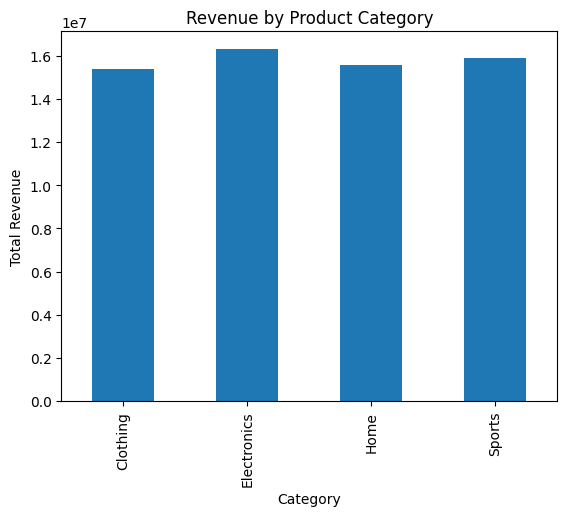

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

category_sales = data.groupby("product_category")["revenue"].sum()

category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
Task: Line chart of revenue over time

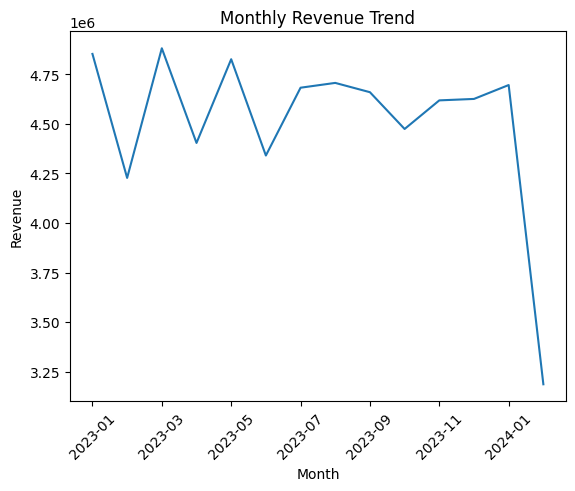

In [12]:
data["month"] = data["order_date"].dt.to_period("M").astype(str)

monthly_sales = data.groupby("month")["revenue"].sum()

monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

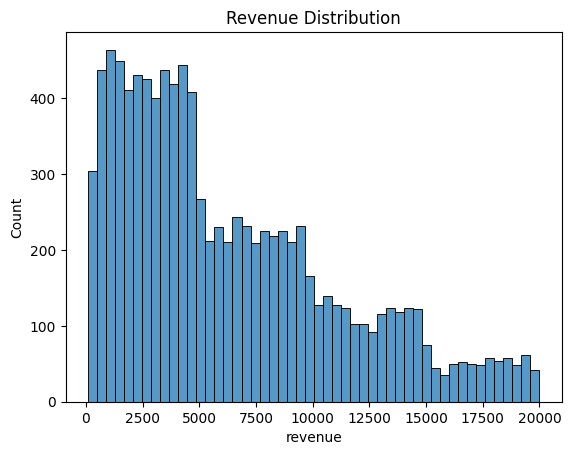

In [13]:
sns.histplot(data["revenue"], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [ ]:
Dataset-- Data Cleaning-- Exploratory Data Analysis-- Feature Engineering-- Model Training-- Model Evaluation-- Model Deployment

In [14]:
from sklearn.model_selection import train_test_split

# Encode category
data_model = pd.get_dummies(data, columns=["product_category"], drop_first=True)

# Features & Target
X = data_model.drop(columns=["order_id", "customer_id", "order_date", "revenue"])
y = data_model["revenue"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Feature engineering
data["year"] = data["order_date"].dt.year
data["month"] = data["order_date"].dt.month
data["day"] = data["order_date"].dt.day

# Encode categorical
data_model = pd.get_dummies(data, columns=["product_category"], drop_first=True)

# Features
X = data_model.drop(columns=["order_id", "customer_id", "order_date", "revenue"])
y = data_model["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

print("Sample Predictions:")
print(y_pred[:5])

Sample Predictions:
[ 4159.0074253  11615.54693715 12824.83441073  4124.84394007
  -512.50009912]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1274.1208941475543
MSE: 2689058.261786114
R2 Score: 0.8910901695939133


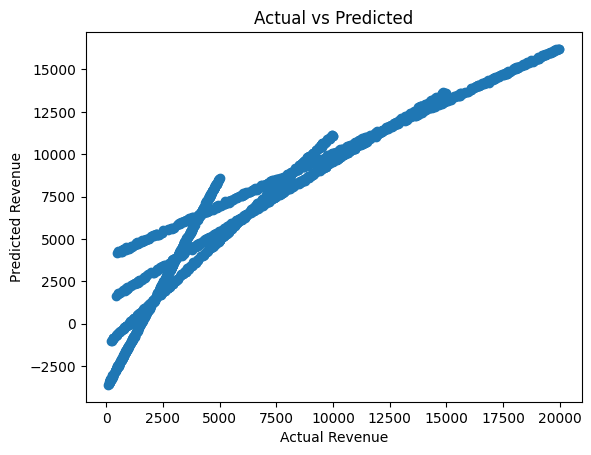

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")
plt.show()

### NLP

In [25]:
import nltk
import spacy
from sentence_transformers import SentenceTransformer

nlp = spacy.load("en_core_web_sm")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("All good ✅")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

All good ✅


In [27]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [30]:
import nltk

# Force download inside your user directory
nltk.download('punkt', download_dir='/Users/navalyemul/nltk_data')
nltk.download('stopwords', download_dir='/Users/navalyemul/nltk_data')

# Tell nltk where to look
nltk.data.path.append('/Users/navalyemul/nltk_data')

print("NLTK setup done ✅")

NLTK setup done ✅


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
import nltk
import os

nltk_data_path = os.path.expanduser("~/nltk_data")
nltk.data.path.append(nltk_data_path)

nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [35]:
import nltk
import os

nltk_data_path = os.path.expanduser("~/nltk_data")

nltk.data.path.append(nltk_data_path)

nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)

print("NLTK setup done ✅")

NLTK setup done ✅


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
import nltk
import os

# Define path
nltk_data_path = os.path.expanduser("~/nltk_data")

# Force path
if nltk_data_path not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_path)

# Force re-download (IMPORTANT)
nltk.download('punkt', download_dir=nltk_data_path, force=True)
nltk.download('stopwords', download_dir=nltk_data_path, force=True)

print("NLTK path:", nltk.data.path)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/navalyemul/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/navalyemul/nltk_data...


NLTK path: ['/Users/navalyemul/nltk_data', '/Users/navalyemul/Documents/uptime/venv/nltk_data', '/Users/navalyemul/Documents/uptime/venv/share/nltk_data', '/Users/navalyemul/Documents/uptime/venv/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data', '/Users/navalyemul/nltk_data', '/Users/navalyemul/nltk_data', '/Users/navalyemul/nltk_data']


[nltk_data]   Unzipping corpora/stopwords.zip.


In [38]:
import nltk

print(nltk.data.find('tokenizers/punkt'))

/Users/navalyemul/nltk_data/tokenizers/punkt


In [40]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()
tokens = tokenizer.tokenize("This product is really amazing")

print(tokens)

['This', 'product', 'is', 'really', 'amazing']


In [34]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

text = "This product is really amazing and worth the money!"

tokens = word_tokenize(text)
stop_words = set(stopwords.words("english"))

clean = [w for w in tokens if w.lower() not in stop_words]

print(clean)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/navalyemul/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/share/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - '/Users/navalyemul/nltk_data'
    - '/Users/navalyemul/nltk_data'
**********************************************************************


In [28]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

text = "This product is really amazing and worth the money!"

tokens = word_tokenize(text)
stop_words = set(stopwords.words("english"))

clean = [w for w in tokens if w.lower() not in stop_words]

print(clean)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/navalyemul/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/share/nltk_data'
    - '/Users/navalyemul/Documents/uptime/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [41]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "Apple launched a new iPhone in India with great battery life"
doc = nlp(text)

# Tokens + POS + Lemma
for token in doc:
    print(token.text, token.pos_, token.lemma_)

Apple PROPN Apple
launched VERB launch
a DET a
new ADJ new
iPhone PROPN iPhone
in ADP in
India PROPN India
with ADP with
great ADJ great
battery NOUN battery
life NOUN life


In [42]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "This phone has great battery life",
    "Battery backup is excellent",
    "The product is very expensive",
    "Camera quality is amazing"
]

embeddings = model.encode(sentences)

print(embeddings.shape)  # (4, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(4, 384)


In [43]:
print("Embedding for first sentence:\n")
print(embeddings[0])

Embedding for first sentence:

[-6.68424964e-02  9.13172588e-02  2.25948151e-02 -1.69896577e-02
 -1.79856550e-02 -2.60191336e-02  1.63031910e-02  4.71552424e-02
  7.92408362e-02  4.01141420e-02 -2.71242689e-02  5.47100306e-02
  1.48865888e-02  3.90407853e-02  2.61970628e-02 -3.13155763e-02
  8.31613168e-02 -8.75166282e-02 -6.03533424e-02 -2.86901630e-02
  3.56831476e-02 -7.05977762e-03  6.00429364e-02  2.06680894e-02
  4.20535840e-02 -1.87854487e-02 -8.20553079e-02  3.30592878e-02
  3.10509857e-02 -4.97229621e-02  5.85146761e-03  1.70404956e-01
  1.03058323e-01  2.41262969e-02 -1.49439555e-02  3.25049534e-02
 -3.97819094e-03  1.71103720e-02  4.66451049e-03  1.88178308e-02
 -1.06439039e-01  4.00190018e-02  4.45578508e-02 -4.09559458e-02
  6.12209029e-02 -1.07576409e-02  1.86975375e-02 -3.17448899e-02
  2.79825255e-02  1.76491737e-02  6.38105795e-02  3.07622254e-02
 -5.88141847e-05 -4.13489640e-02 -7.11254925e-02  3.15138437e-02
 -4.27528732e-02  9.13502648e-03  9.44118649e-02  4.3979559

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity([embeddings[0]], [embeddings[1]])

print("Similarity:", sim[0][0])

Similarity: 0.47740692


In [ ]:
import keyword


NLKT--- keyword
spcy-- keyword noun, pronoun
sentence transformer-- embedding